In [1]:
import pandas as pd
import numpy as np
import re
import os
import random
import requests
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    confusion_matrix
)

In [2]:
# Cell 2

test_probs = np.load("/Users/amarachi/Documents/AQA/Exp_3/phase4/Notebook/phase4_outputs/test_preds.npy")
test_preds = np.load("/Users/amarachi/Documents/AQA/Exp_3/phase4/Notebook/phase4_outputs/test_preds.npy")

y_test = np.load("/Users/amarachi/Documents/AQA/Exp_3/phase3/notebook /phase3_features/y_test.npy")

test_df = pd.read_csv("/Users/amarachi/Documents/AQA/Exp_3/phase2/Notebook/strict_splits/test.csv")

print("Predictions loaded")
print("Test samples:", len(test_probs))
print("Loaded test predictions")
print("Test dataset loaded")


test_df.head()

Predictions loaded
Test samples: 355
Loaded test predictions
Test dataset loaded


,text,label,source_document
0,e-governance mission mode project (mmp) crime ...,1,0000 - cctns.csv
1,description of the modules and functional requ...,1,0000 - cctns.csv
2,registration citizens can register their compl...,0,0000 - cctns.csv
3,citizens can register their complaints with po...,0,0000 - cctns.csv
4,non-functional requirements the non-functional...,1,0000 - cctns.csv


In [3]:
RKG = {

# Aerospace
"weak_modal": "DO-178C §A-5 – Requirements must be precise and verifiable",
"verification": "DO-178C §6.3 – Software verification must ensure correctness",
"traceability": "DO-178C §11.21 – Requirements must be traceable",

# Automotive
"vague_term": "ISO 26262 §7.4.3 – Requirements shall be precise and unambiguous",
"safety": "ISO 26262 §6.4.2 – Safety requirements must be clearly specified",
"timing": "ISO 26262 §7.4.11 – Timing constraints must be defined",

# Medical
"quantifier": "IEC 62304 §5.2 – Software requirements must be measurable",
"risk": "IEC 62304 §7.1 – Risk management requirements",

# Railway
"ambiguity": "EN 50128 §6.2 – Requirements must avoid ambiguity",

# Systems Engineering
"frequency": "ISO/IEC/IEEE 29148 §6.3 – Requirements shall be verifiable and measurable",
"clarity": "ISO/IEC/IEEE 29148 §5.2 – Requirements must be clear and testable"
}

In [4]:
tau = best_threshold

Decision threshold τ = 0.29


In [5]:
def detect_trigger(text):

    text = text.lower()

    if re.search(r"\bmay\b|\bshould\b|\bcould\b|\bmight\b", text):
        return "weak_modal"

    if re.search(r"\badequate\b|\bappropriate\b|\btimely\b|\bsufficient\b", text):
        return "vague_term"

    if re.search(r"\bsome\b|\bmany\b|\bseveral\b|\bfew\b", text):
        return "quantifier"

    if re.search(r"\boften\b|\bsometimes\b|\boccasionally\b", text):
        return "frequency"

    return "clarity"

In [6]:
def map_clause(trigger):

    if trigger in RKG:
        return RKG[trigger]

    return RKG["clarity"]

In [7]:
def short_recommendation(trigger):

    if trigger == "weak_modal":
        return "Replace weak modal with 'shall'."

    if trigger == "vague_term":
        return "Replace vague wording with measurable value."

    if trigger == "quantifier":
        return "Specify exact quantity."

    if trigger == "frequency":
        return "Define precise timing."

    return "Clarify requirement wording."

In [8]:
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL = "mistral:7b-instruct"

In [9]:
def ollama_recommendation(requirement):

    prompt = f"""
A software requirement may contain ambiguity.

Requirement:
{requirement}

Provide a SHORT recommendation to improve clarity.
One sentence only.
"""

    payload = {
        "model": MODEL,
        "prompt": prompt,
        "stream": False
    }

    try:
        response = requests.post(OLLAMA_URL, json=payload)

        if response.status_code == 200:
            return response.json()["response"].strip()

    except:
        pass

    return ""

In [10]:
results = []

for i,row in test_df.iterrows():

    requirement = row["text"]

    hybrid_score = float(test_probs[i])

    decision = "Ambiguous" if hybrid_score >= tau else "Clear"

    trigger = detect_trigger(requirement)

    clause = map_clause(trigger)

    recommendation = ""

    if decision == "Ambiguous":

        recommendation = ollama_recommendation(requirement)

    results.append({

        "requirement": requirement,
        "hybrid_score": hybrid_score,
        "threshold": tau,
        "decision": decision,
        "clause": clause,
        "recommendation": recommendation

    })

In [11]:
results_df = pd.DataFrame(results)

print("Generated rows:", results_df.shape)

results_df.head()

Generated rows: (355, 6)


,requirement,hybrid_score,threshold,decision,clause,recommendation
0,e-governance mission mode project (mmp) crime ...,1.0,0.29,Ambiguous,DO-178C §A-5 – Requirements must be precise an...,Replace weak modal with 'shall'.
1,description of the modules and functional requ...,1.0,0.29,Ambiguous,ISO/IEC/IEEE 29148 §5.2 – Requirements must be...,Clarify requirement wording.
2,registration citizens can register their compl...,1.0,0.29,Ambiguous,ISO/IEC/IEEE 29148 §5.2 – Requirements must be...,Clarify requirement wording.
3,citizens can register their complaints with po...,1.0,0.29,Ambiguous,ISO/IEC/IEEE 29148 §5.2 – Requirements must be...,Clarify requirement wording.
4,non-functional requirements the non-functional...,1.0,0.29,Ambiguous,DO-178C §A-5 – Requirements must be precise an...,Replace weak modal with 'shall'.


In [12]:
examples = results_df.sample(5, random_state=42)

for _,row in examples.iterrows():

    print(row["requirement"])
    print(f"Hybrid: {row['hybrid_score']:.4f} (τ={row['threshold']}) → {row['decision']}")
    print("Clause:", row["clause"])

    if row["decision"] == "Ambiguous":

        print("Recommendation:", row["recommendation"])
        #print("Rewrite:", row["rewrite"])

    print()

the autosar development collaboration support shall include processes, exchange formats and methodology.
Hybrid: 0.0000 (τ=0.29) → Clear
Clause: ISO/IEC/IEEE 29148 §5.2 – Requirements must be clear and testable

writing style: the reading and understanding of the textual content on the screen should be supported by suitable means, including the use of short sentences, the division of the text into shorter chunks or the presentation of content items in the form of bullet points.
Hybrid: 1.0000 (τ=0.29) → Ambiguous
Clause: DO-178C §A-5 – Requirements must be precise and verifiable
Recommendation: Replace weak modal with 'shall'.


KeyError: 'rewrite'

In [13]:
examples = results_df.sample(5, random_state=42)

for _,row in examples.iterrows():

    print(row["requirement"])
    print(f"Hybrid: {row['hybrid_score']:.4f} (τ={row['threshold']}) → {row['decision']}")
    print("Clause:", row["clause"])

    if row["decision"] == "Ambiguous":

        print("Recommendation:", row["recommendation"])
        #print("Rewrite:", row["rewrite"])

    print()

the autosar development collaboration support shall include processes, exchange formats and methodology.
Hybrid: 0.0000 (τ=0.29) → Clear
Clause: ISO/IEC/IEEE 29148 §5.2 – Requirements must be clear and testable

writing style: the reading and understanding of the textual content on the screen should be supported by suitable means, including the use of short sentences, the division of the text into shorter chunks or the presentation of content items in the form of bullet points.
Hybrid: 1.0000 (τ=0.29) → Ambiguous
Clause: DO-178C §A-5 – Requirements must be precise and verifiable
Recommendation: Replace weak modal with 'shall'.

to achieve a common standard, which is accepted and used by all of the participating partners these solutions shall be consolidated by autosar.
Hybrid: 1.0000 (τ=0.29) → Ambiguous
Clause: ISO/IEC/IEEE 29148 §5.2 – Requirements must be clear and testable
Recommendation: Clarify requirement wording.

many constraints are defined in the base specification. in addit

In [14]:
os.makedirs("phase5_outputs", exist_ok=True)

results_df.to_csv(
    "phase5_outputs/radar_recommendations.csv",
    index=False
)

print("Results saved")

Results saved


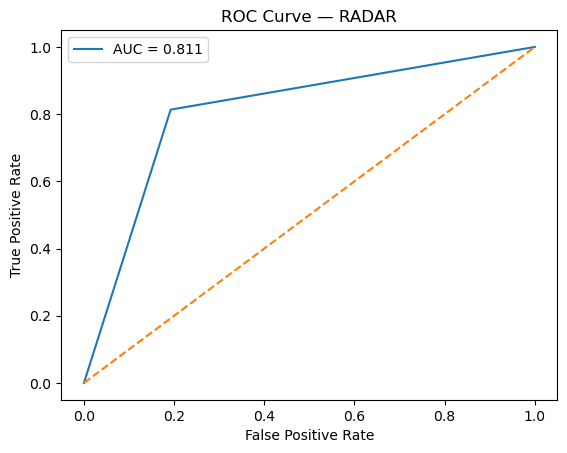

In [15]:
fpr, tpr, _ = roc_curve(y_test, test_probs)

auc_score = roc_auc_score(y_test, test_probs)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — RADAR")

plt.legend()
plt.show()

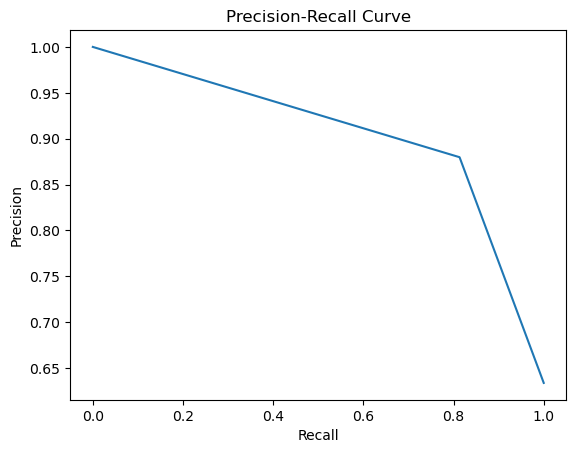

In [16]:
precision, recall, _ = precision_recall_curve(y_test, test_probs)

plt.figure()

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

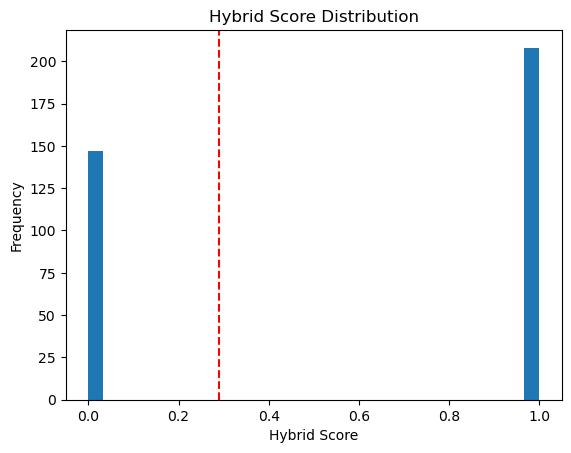

In [17]:
plt.figure()

plt.hist(test_probs, bins=30)

plt.axvline(tau, color='red', linestyle='--')

plt.title("Hybrid Score Distribution")
plt.xlabel("Hybrid Score")
plt.ylabel("Frequency")

plt.show()

In [18]:
 from sklearn.metrics import classification_report

In [19]:
classification_report(y_test, test_probs >= 0.5)
classification_report(y_test, test_probs >= tau)

'              precision    recall  f1-score   support\n\n           0       0.71      0.81      0.76       130\n           1       0.88      0.81      0.85       225\n\n    accuracy                           0.81       355\n   macro avg       0.80      0.81      0.80       355\nweighted avg       0.82      0.81      0.81       355\n'

In [20]:
roc_auc_score(y_test, test_probs)

np.float64(0.8105128205128205)

In [ ]:
## Advanced Evaluation (Journal-Level Analysis)

Brier Score: 0.18873239436619718


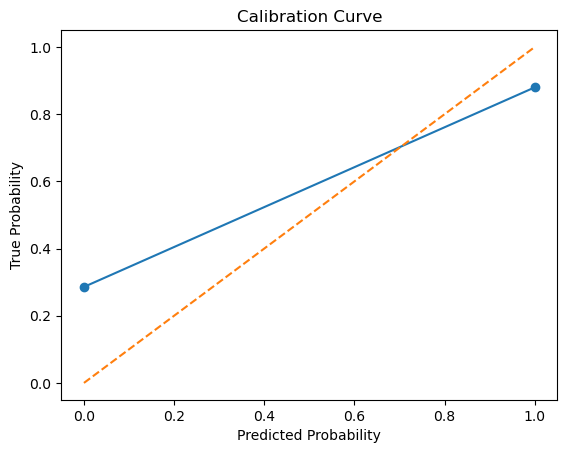

In [22]:
# CALIBRATION METRICS

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Brier Score
brier = brier_score_loss(y_test, test_probs)
print("Brier Score:", brier)

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()

In [23]:
# EXPECTED CALIBRATION ERROR (ECE)
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            ece += np.abs(acc - conf) * np.sum(mask) / len(y_prob)
    
    return ece

ece = compute_ece(y_test, test_probs)
print("ECE:", ece)

ECE: 0.11830985915492957


In [26]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

In [28]:
# BOOTSTRAP CONFIDENCE INTERVALS

from sklearn.utils import resample
import numpy as np

def bootstrap_metric(y_true, y_pred, metric_fn, n=1000):
    scores = []
    n_samples = len(y_true)
    
    for _ in range(n):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_t = y_true[indices]
        y_p = y_pred[indices]
        scores.append(metric_fn(y_t, y_p))
    
    return np.percentile(scores, [2.5, 97.5])

ci_f1 = bootstrap_metric(y_test, test_preds, f1_score)
print("F1 95% CI:", ci_f1)

F1 95% CI: [0.80567002 0.88128237]


In [29]:
# RISK-SENSITIVE EXPERIMENT

cost_settings = [
    (1,1),   # balanced
    (1,3),   # medium risk
    (1,5),   # high risk
]

for C_fp, C_fn in cost_settings:
    tau = C_fp / (C_fp + C_fn)
    
    preds = (test_probs >= tau).astype(int)
    
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    
    print(f"\nCost FP={C_fp}, FN={C_fn}")
    print("Threshold:", tau)
    print("Precision:", p)
    print("Recall:", r)
    print("F1:", f)


Cost FP=1, FN=1
Threshold: 0.5
Precision: 0.8798076923076923
Recall: 0.8133333333333334
F1: 0.8452655889145496

Cost FP=1, FN=3
Threshold: 0.25
Precision: 0.8798076923076923
Recall: 0.8133333333333334
F1: 0.8452655889145496

Cost FP=1, FN=5
Threshold: 0.16666666666666666
Precision: 0.8798076923076923
Recall: 0.8133333333333334
F1: 0.8452655889145496


In [30]:
# ERROR ANALYSIS

errors = test_df.copy()
errors["pred"] = test_preds
errors["prob"] = test_probs

false_negatives = errors[(errors["label"]==1) & (errors["pred"]==0)]
false_positives = errors[(errors["label"]==0) & (errors["pred"]==1)]

print("False Negatives:", len(false_negatives))
print("False Positives:", len(false_positives))

# show examples
print("\nSample FN:")
print(false_negatives["text"].head(5))

print("\nSample FP:")
print(false_positives["text"].head(5))

False Negatives: 42
False Positives: 25

Sample FN:
104    req-5: sorting results should take less than 0...
124    the system shall be able to handle 1000 custom...
125    the system shall be able to retrieve 200 produ...
126    the system shall be able to add product to sho...
127    the system shall be able to search for a speci...
Name: text, dtype: object

Sample FP:
2      registration citizens can register their compl...
3      citizens can register their complaints with po...
150       the system shall employ easy to locate buttons
201    main requirements autosar fo r24-11 △ rational...
216    platforms designed for the support of safety r...
Name: text, dtype: object


In [32]:
for C_fp, C_fn in cost_settings:
    tau = C_fp / (C_fp + C_fn)
    
    preds = (test_probs >= tau).astype(int)
    
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    
    print(f"\nCost FP={C_fp}, FN={C_fn}")
    print(f"Threshold: {tau:.3f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall: {r:.4f}")
    print(f"F1: {f:.4f}")


Cost FP=1, FN=1
Threshold: 0.500
Precision: 0.8798
Recall: 0.8133
F1: 0.8453

Cost FP=1, FN=3
Threshold: 0.250
Precision: 0.8798
Recall: 0.8133
F1: 0.8453

Cost FP=1, FN=5
Threshold: 0.167
Precision: 0.8798
Recall: 0.8133
F1: 0.8453


In [34]:
print(np.unique(test_probs[:20]))

[1]


In [35]:
import numpy as np

print("Min prob:", np.min(test_probs))
print("Max prob:", np.max(test_probs))

print("Unique (rounded):", np.unique(np.round(test_probs, 2))[:20])

Min prob: 0
Max prob: 1
Unique (rounded): [0 1]


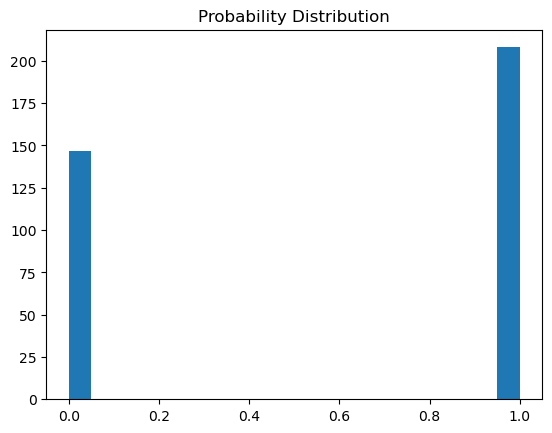

In [36]:
import matplotlib.pyplot as plt

plt.hist(test_probs, bins=20)
plt.title("Probability Distribution")
plt.show()